In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from math import sin, cos, sqrt, gcd, pi
import pandas as pd

In [18]:
def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        # floor += (1 - floor) / n
        # k = 1 - floor
        x, y, z = xyz        
    return colors

In [19]:

tourney_df = pd.read_pickle('pickle/tourney_w_brackets_df.p')
tourney_df = tourney_df[
    (tourney_df['Iowa'] > 2) 
    & (tourney_df['Purdue'] > 2)
    & (tourney_df['Arizona'] > 2)
    & (tourney_df['Illinois'] > 2)
    & (tourney_df['Duke'] > 2)
    & (tourney_df['Michigan'] > 2)
    & (tourney_df['Connecticut'] > 2)
    & (tourney_df['Tennessee'] > 2)
    ]

tourney_df['Probability'] = tourney_df['Probability']/tourney_df['Probability'].sum()

current_df = tourney_df[['Winner', 'Probability']].groupby('Winner').sum().sort_values('Probability', ascending = False)
current_df['Probability'] = current_df['Probability']/current_df['Probability'].sum()

prize_cols = ['Winner', 'Second', 'Third']
titles = {'Winner' : '1st Place', 
          'Second' : '2nd Place', 
          'Third' : '3rd Place'}
disp_titles = []
all_labels = []
dfs = [current_df]

game1 = ["Iowa", "Illinois"]
game2 = ["Purdue", "Arizona"]


In [20]:
all_labels = list(current_df.index)
all_colors = get_color_list(len(all_labels), 1, 0.5, start=0)
color_dict = {label: color for label, color in zip(all_labels, all_colors)}




In [21]:
def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        # floor += (1 - floor) / n
        # k = 1 - floor
        x, y, z = xyz        
    return colors

In [22]:
seen = set()
final_labels = []
for label in all_labels:
    if label not in seen:
        final_labels.append(label)
        seen.add(label)
        
for label in sorted(seen):
    print(label)
        
n = len(final_labels)
step = 1
while gcd(step, n) > 1:
    step += 1
floor = 0.5
colors = get_color_list(n, step, floor, start=0)
color_dict = {label: color for label, color in zip(final_labels, colors)}

color_dict

George Wright
Keith Schneider
Keith Schneider, Mark Hurst
Keith Schneider, Mark Hurst, Tyler Krause
Keith Schneider, Tyler Krause
Koy Kubasta
Mark Hurst
Nathan Sanches
Patrick Commers
Tyler Krause


{'George Wright': [0.5690355937288492, 0.9633731610262555, 0.6746980264314426],
 'Nathan Sanches': [0.5029018859509458,
  0.8840344990789524,
  0.8201703961566492],
 'Tyler Krause': [0.5256900086171656, 0.7480379635819384, 0.9333788089874432],
 'Patrick Commers': [0.6286956734088147,
  0.6073296087428415,
  0.9710814990348912],
 'Keith Schneider': [0.7725742174092615,
  0.5156552436091156,
  0.9188773201681703],
 'Koy Kubasta': [0.9023689270621824, 0.5080313597647761, 0.796706494359589],
 'Mark Hurst': [0.9685026348400858, 0.5873700217120792, 0.6512341246343825],
 'Keith Schneider, Tyler Krause': [0.9457145121738659,
  0.723366557209093,
  0.5380257118035884],
 'Keith Schneider, Mark Hurst': [0.8427088473822169,
  0.8640749120481901,
  0.5003230217561404],
 'Keith Schneider, Mark Hurst, Tyler Krause': [0.6988303033817701,
  0.9557492771819159,
  0.5525272006228613]}

In [23]:
for winner in game1:
    print(winner)

    
    sub_df = tourney_df.loc[tourney_df[winner] > 3].copy()
    sub_df['Probability'] = sub_df['Probability']/sub_df['Probability'].sum()
    grouped_df = sub_df[['Winner', 'Probability']].groupby('Winner').sum().sort_values('Probability', ascending = False)
    dfs.append(grouped_df)

Iowa
Illinois


In [24]:
for winner in game1:
    for winner2 in game2:
        print(winner, winner2)


        sub_df = tourney_df.loc[(tourney_df[winner] > 3) & (tourney_df[winner2] > 3)].copy()
        sub_df['Probability'] = sub_df['Probability']/sub_df['Probability'].sum()
        grouped_df = sub_df[['Winner', 'Probability']].groupby('Winner').sum().sort_values('Probability', ascending = False)
        dfs.append(grouped_df)

Iowa Purdue
Iowa Arizona
Illinois Purdue
Illinois Arizona


In [25]:
dfs

[                                           Probability
 Winner                                                
 George Wright                                 0.213884
 Nathan Sanches                                0.204518
 Tyler Krause                                  0.195762
 Patrick Commers                               0.154172
 Keith Schneider                               0.102921
 Koy Kubasta                                   0.058676
 Mark Hurst                                    0.030517
 Keith Schneider, Tyler Krause                 0.026085
 Keith Schneider, Mark Hurst                   0.008049
 Keith Schneider, Mark Hurst, Tyler Krause     0.005415,
                                            Probability
 Winner                                                
 George Wright                                 0.229522
 Nathan Sanches                                0.203058
 Tyler Krause                                  0.197231
 Patrick Commers                               

In [26]:
def shift_pie(pie_elements, dx):
    slices, labels, percents = pie_elements
    for slice in slices:
        slice.set_center([dx, 0.0])
    for label in labels:
        x, y = label.get_position()
        label.set_position([x + dx, y])
    for percent in percents:
        x, y = percent.get_position()
        percent.set_position([x + dx, y])
    

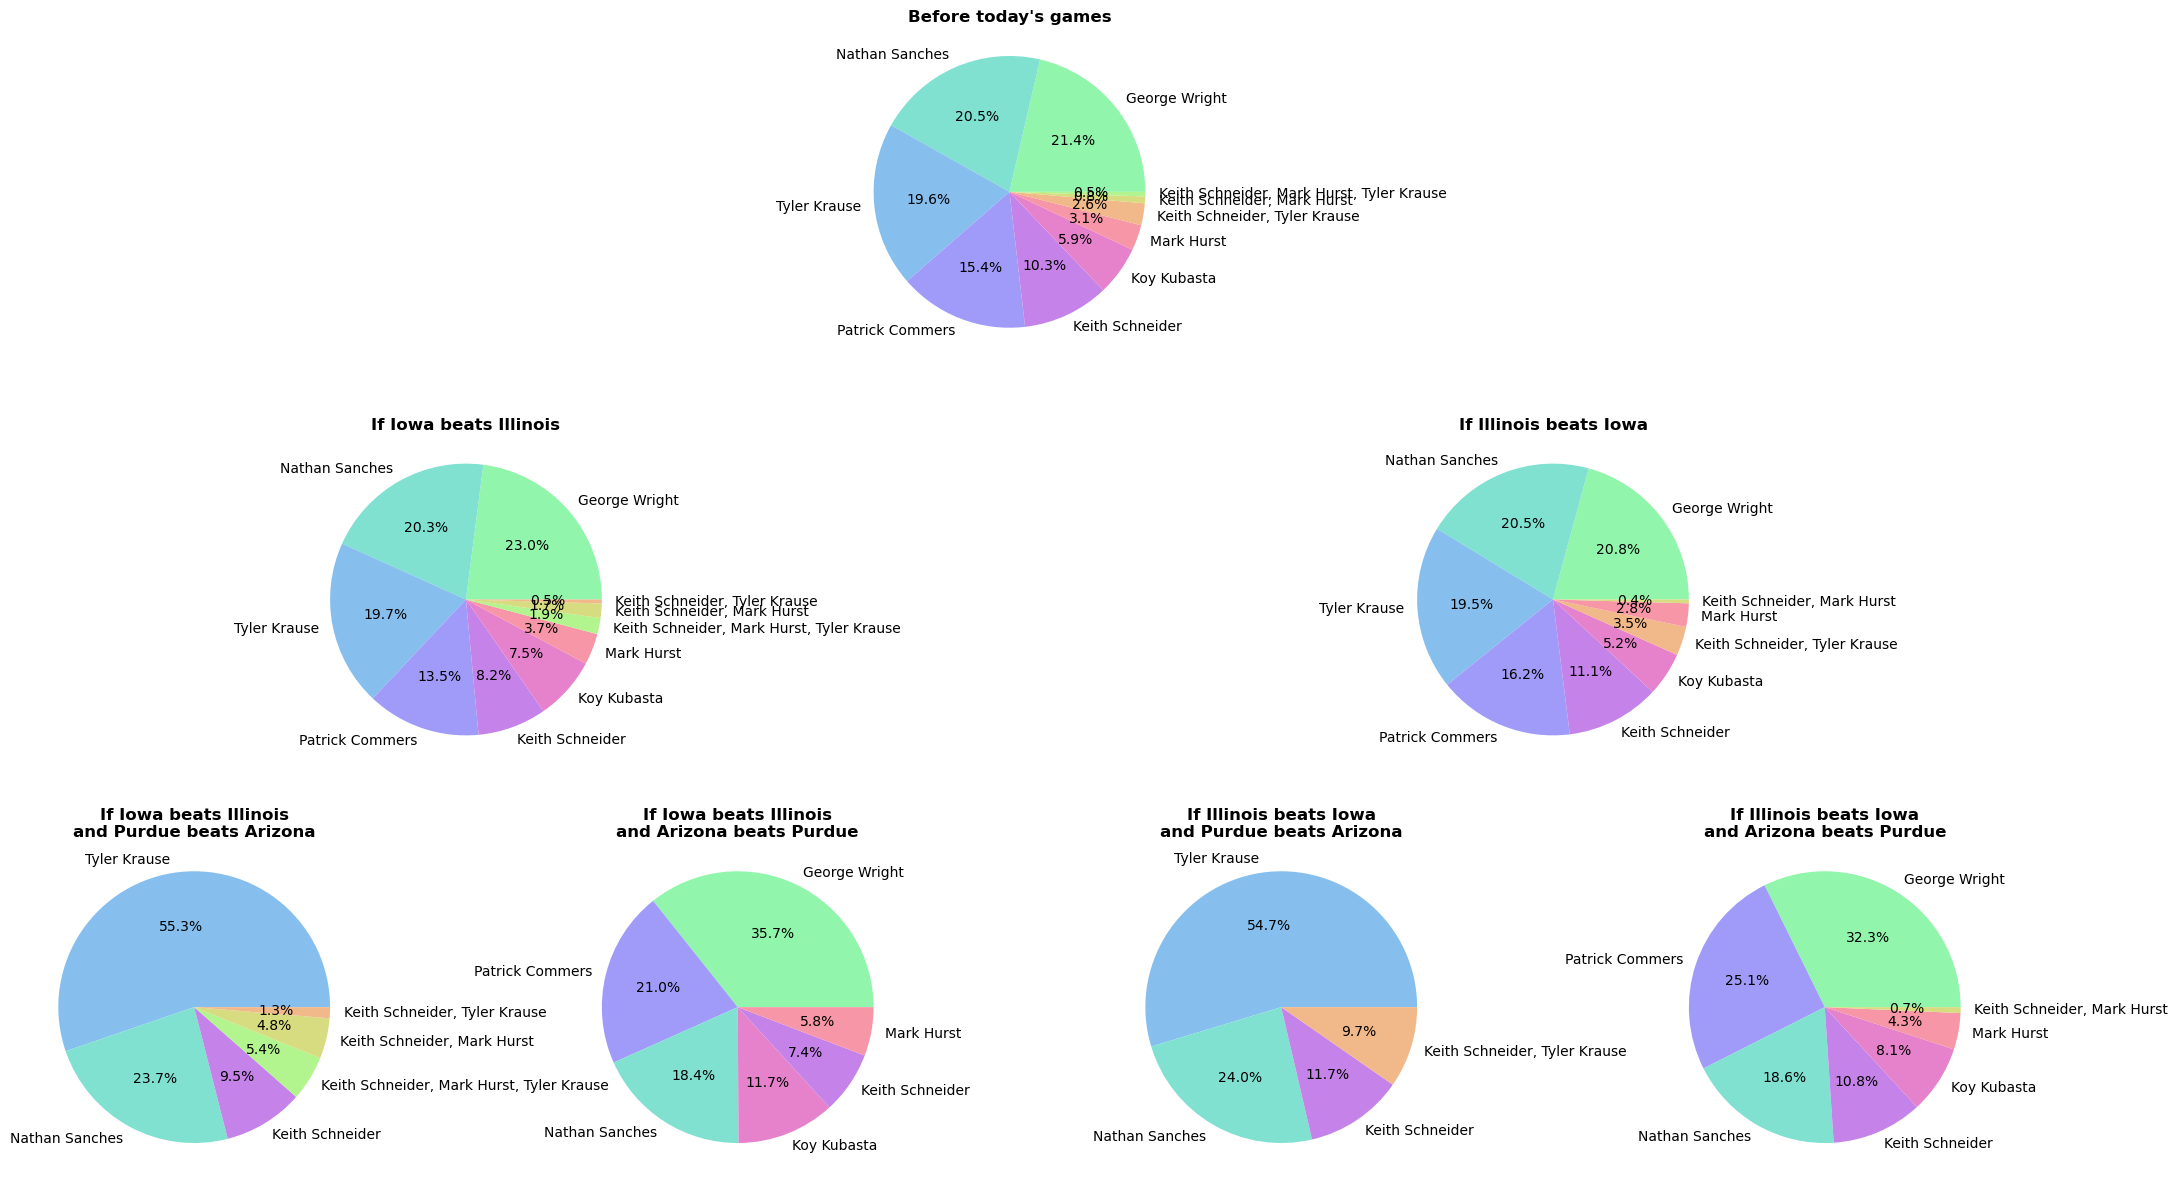

In [27]:
fig, axs = plt.subplots(3, 1, figsize = [10, 15])


ax = axs[0]
df = dfs[0]
labels = df.index
labels = [_ if _ != long_label else short_label for _ in labels]

colors = [color_dict[label] for label in labels]

pie0 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)

title="Before today's games"
ax.text(0, 1.25, title, ha='center', fontsize='large', fontweight='bold')

ax = axs[1]
df = dfs[1]
labels = df.index
labels = [_ if _ != long_label else short_label for _ in labels]
colors = [color_dict[label] for label in labels]

pie1 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie1, -4)

title = f"If {game1[0]} beats {game1[1]}"
ax.text(-4, 1.25, title, ha='center', fontsize='large', fontweight='bold')

df = dfs[2]
labels = df.index
labels = [_ if _ != long_label else short_label for _ in labels]
colors = [color_dict[label] for label in labels]

pie2 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie2, 4)

title = f"If {game1[1]} beats {game1[0]}"
ax.text(4, 1.25, title, ha='center', fontsize='large', fontweight='bold')

ax = axs[2]

df = dfs[3]
labels = df.index
labels = [_ if _ != long_label else short_label for _ in labels]
colors = [color_dict[label] for label in labels]

pie3 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie3, -6)

title = f"If {game1[0]} beats {game1[1]}\nand {game2[0]} beats {game2[1]}"
ax.text(-6, 1.25, title, ha='center', fontsize='large', fontweight='bold')

df = dfs[4]
labels = df.index

colors = [color_dict[label] for label in labels]

pie4 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie4, -2)

title = f"If {game1[0]} beats {game1[1]}\nand {game2[1]} beats {game2[0]}"
ax.text(-2, 1.25, title, ha='center', fontsize='large', fontweight='bold')

df = dfs[5]
labels = df.index
labels = [_ if _ != long_label else short_label for _ in labels]
colors = [color_dict[label] for label in labels]

pie5 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie5, 2)

title = f"If {game1[1]} beats {game1[0]}\nand {game2[0]} beats {game2[1]}"
ax.text(2, 1.25, title, ha='center', fontsize='large', fontweight='bold')

df = dfs[6]
labels = df.index
labels = [_ if _ != long_label else short_label for _ in labels]
colors = [color_dict[label] for label in labels]

pie6 = ax.pie(df['Probability'], 
              labels=labels,
              autopct='%1.1f%%',
              normalize=True,
              colors=colors)
shift_pie(pie6, 6)

title = f"If {game1[1]} beats {game1[0]}\nand {game2[1]} beats {game2[0]}"
ax.text(6, 1.25, title, ha='center', fontsize='large', fontweight='bold')
plt.savefig('plots/two_game_tree.png', dpi=300, bbox_inches='tight')